**Navigation** : [Index](README.md) | [<< Précédent](10_LocalLlama.ipynb) | [Suivant >>](11_Quantization.ipynb)

# 10c. Stratégies pour contextes longs — budget de tokens, biais de position, map-reduce, prefix caching

**Durée estimée** : 50 minutes

**Prérequis** : Notebook 1 (OpenAI Intro), 10 (Hébergement local — vLLM), compréhension du comptage de tokens.

***

## Objectifs

Nos notebooks consomment des contextes de plus en plus longs (RAG multi-documents, PDF, conversations multi-tours). Pourtant, **aucun** ne répond à la question du *comment* : comment décider si un contexte tient dans la fenêtre servant, comment le modèle lit réellement une longue entrée, et comment économiser à la fois des tokens et de la latence.

Ce notebook **mesure**, sur notre propre pile self-hosted (vLLM), quatre stratégies de gestion du long contexte :

| # | Stratégie | Ce qu'on mesure |
|---|---|---|
| 1 | **Compter avant d'envoyer** | Le coût réel en tokens d'un corpus, la décision « ça tient / ça ne tient pas » |
| 2 | **Biais de position** | Le rappel d'un fait saillant en fonction de sa profondeur (needle-in-haystack → « lost in the middle ») |
| 3 | **Réordonnancement** | L'effet de placer le document critique au début / milieu / fin |
| 4 | **Map-reduce vs troncation** | La perte d'information quantifiée entre résumer-then-synthétiser et tronquer naïvement |
| 5 | **Coût réel (latence)** | Le gain de latence du **prefix caching** vLLM (cache hit = latence mesurée, pas affirmée) |

> **Différenciateur.** Chaque courbe et chaque chiffre viennent d'une **exécution réelle** sur notre vLLM distant — pas d'un folklore, pas d'une valeur codée en dur. Sorties committées (C.2) : ce qu'un cours sur une API tierce ne peut pas montrer de l'intérieur.

***

## Pourquoi c'est un sujet à part entière

Le découpage `chunks` du RAG, le `max_tokens` d'un appel, l'ordre des documents ingérés : tout cela repose sur l'hypothèse que le modèle « lit » uniformément sa fenêtre. Or cette hypothèse est **fausse**, et le coût de l'ignorer est double : on paie des tokens pour un contenu que le modèle n'utilise pas (biais de position), et on sous-exploite un cache capable de diviser la latence par deux (prefix caching).

Ce notebook n'énonce pas ces faits — il les **fait mesurer**.

In [1]:
%matplotlib inline
# Imports, config de l'endpoint, et ancrage du repo (tout en un)
import os, json, time, random, statistics, re
from pathlib import Path
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import requests

# --- 1) Endpoint self-hosted vLLM, lu depuis l'environnement (jamais en clair ici) ---
VLLM_BASE_URL = os.getenv("VLLM_BASE_URL", "http://192.168.0.47:5002/v1")
VLLM_MODEL = os.getenv("VLLM_MODEL", "qwen3.6-35b-a3b")
VLLM_API_KEY = os.getenv("VLLM_API_KEY", None)
if not VLLM_API_KEY:
    # C'est un secret : il se fournit via une variable d'environnement au moment de l'exec,
    # jamais en dur dans le notebook (regle secrets-hygiene).
    raise ValueError("VLLM_API_KEY manquant — definir la variable d'env avant d'executer ce notebook.")

HEADERS = {"Authorization": f"Bearer {VLLM_API_KEY}", "Content-Type": "application/json"}

# --- 2) Tokenizer reel (famille Qwen), chargé hors-ligne, reproductible ---
from transformers import AutoTokenizer
TOKENIZER = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-0.5B-Instruct", local_files_only=True)

# --- 3) Ancrage du repo : on remonte jusqu'au dossier contenant MyIA.AI.Notebooks ---
def repo_root():
    p = Path.cwd()
    while not (p / "MyIA.AI.Notebooks").exists() and p.parent != p:
        p = p.parent
    return p

ROOT = repo_root()

def corpus_path(name):
    # le_horla et boule_de_suif sont des corpus deja suivis par git dans la serie Audio
    return ROOT / "MyIA.AI.Notebooks" / "GenAI" / "Audio" / "04-Applications" / name

CORPUS_HORLA = corpus_path("datasets/le_horla_1887.txt")
CORPUS_BOULE = corpus_path("boule_de_suif_full.txt")

print("vLLM :", VLLM_BASE_URL, "| modele :", VLLM_MODEL)
print("corpus Horla present :", CORPUS_HORLA.exists())
print("corpus Boule present :", CORPUS_BOULE.exists())

vLLM : http://192.168.0.47:5002/v1 | modele : qwen3.6-35b-a3b
corpus Horla present : True
corpus Boule present : True


In [2]:
# Helpers : appel chat non-stream + stream (pour le TTFT), tokenizer, score
# Note modele « raisonnant » : qwen3.6-35b-a3b est un modele de type « thinking » — il emet
# d'abord un raisonnement (`message.reasoning`) puis seulement la reponse (`message.content`).
# Sans desactivation, les `max_completion_tokens` sont consommes par le raisonnement et la
# reponse reste `content=None` (finish_reason=length). On desactive donc le raisonnement :
# reponse directe, rapide et deterministe (crucial pour des mesures reproductibles).
_THINKING_OFF = {"chat_template_kwargs": {"enable_thinking": False}}

def chat(prompt, system=None, max_tokens=256, temperature=0.0):
    # Appel chat/simple (non stream) -> contenu. Un maximum de determinisme pour les mesures.
    messages = []
    if system:
        messages.append({"role": "system", "content": system})
    messages.append({"role": "user", "content": prompt})
    payload = {"model": VLLM_MODEL, "messages": messages,
               "max_completion_tokens": max_tokens, "temperature": temperature, **_THINKING_OFF}
    r = requests.post(f"{VLLM_BASE_URL}/chat/completions", headers=HEADERS, json=payload, timeout=180)
    r.raise_for_status()
    # content peut rester None si la reponse est tronquee pendant le raisonnement ; avec
    # _THINKING_OFF ce ne devrait pas arriver, mais on ne fait jamais confiance au None.
    out = r.json()["choices"][0]["message"].get("content") or ""
    return out

def chat_stream_ttft(prompt, system=None, max_tokens=32, temperature=0.0):
    # Appel stream -> (time_to_first_token, contenu). Le TTFT isole le cout de prefilling/cache.
    messages = []
    if system:
        messages.append({"role": "system", "content": system})
    messages.append({"role": "user", "content": prompt})
    payload = {"model": VLLM_MODEL, "messages": messages,
               "max_completion_tokens": max_tokens, "temperature": temperature,
               "stream": True, **_THINKING_OFF}
    t0 = time.perf_counter()
    first = None
    content = []
    with requests.post(f"{VLLM_BASE_URL}/chat/completions", headers=HEADERS, json=payload,
                       timeout=180, stream=True) as r:
        r.raise_for_status()
        for line in r.iter_lines():
            if not line:
                continue
            line = line.decode("utf-8")
            if not line.startswith("data:"):
                continue
            data = line[5:].strip()
            if data == "[DONE]":
                break
            try:
                delta = json.loads(data)["choices"][0]["delta"].get("content", "")
            except Exception:
                continue
            if delta:
                content.append(delta)
                if first is None:
                    first = time.perf_counter() - t0
    return (first if first is not None else time.perf_counter() - t0), "".join(content)

def count_tokens(text):
    return len(TOKENIZER.encode(text))

def simple_score(target, answer):
    # 1 si la reponse contient la cible (forme normalisee), sinon 0. Honnetete : on imprime les deux.
    answer = answer or ""  # jamais de None (modele raisonnant tronque)
    norm = lambda s: re.sub(r"[^0-9a-zA-Z]", "", s.lower())
    return int(norm(target) in norm(answer))

# controle de l'endpoint + lecture de la fenetre REELLE du modele servi (honnete, pas supposee)
def ping():
    r = requests.get(f"{VLLM_BASE_URL}/models", headers=HEADERS, timeout=30)
    if r.status_code != 200:
        return r.status_code, None
    try:
        mlen = r.json()["data"][0].get("max_model_len")
    except Exception:
        mlen = None
    return r.status_code, mlen

_ps, _mlen = ping()
print("endpoint /models ->", _ps, "| max_model_len (fenetre reelle du modele servi) :", _mlen)
REAL_WINDOW = _mlen

endpoint /models -> 200 | max_model_len (fenetre reelle du modele servi) : 262144


## 1. Compter avant d'envoyer — le budget de tokens réel

La première stratégie de gestion du long contexte n'est pas une astuce de modèle : c'est **ne pas dépasser la fenêtre**. Pour cela il faut savoir compter — non pas « à la louche », mais avec le **tokenizer réel** du modèle.

On charge un vrai corpus (une œuvre du domaine public, déjà suivie par git dans la série Audio), on le tokenise, et on calcule ce que coûterait l'envoi de plusieurs documents d'un coup vs un par un. La décision « ça tient / ça ne tient pas » devient un calcul, pas une intuition.

> **Fenêtre réelle vs budget de travail.** Nous travaillons ici sur un **budget volontairement borné** (32 768 tokens), bien plus petit que la **fenêtre réelle** du modèle servi — lue à l'exécution via `/models` (cellule suivante). C'est la situation réaliste d'un pipeline contraint en coût/latence, et c'est elle qui motive les stratégies de découpe des sections 2 à 5.

In [3]:
# 1.1 Charger le vrai corpus et le tokeniser
horla_text = CORPUS_HORLA.read_text(encoding="utf-8", errors="ignore")
boule_text = CORPUS_BOULE.read_text(encoding="utf-8", errors="ignore")

print("Le Horla :", len(horla_text), "caracteres |", count_tokens(horla_text), "tokens")
print("Boule de Suif :", len(boule_text), "caracteres |", count_tokens(boule_text), "tokens")

# Fenetre REELLE du modele servi (lue via /models, cellules precedentes). La demo travaille
# sur un budget de travail CHOISI (plus petit) pour illustrer un contenu qui le DEPASSE
# (contrainte de cout / latence / pipeline) — la fenetre reelle du modele est plus large.
WINDOW = int(os.getenv("VLLM_CONTEXT_WINDOW", "32768"))
print("Fenetre reelle du modele servi (via /models) :", REAL_WINDOW, "tokens")
print("Budget de travail choisi pour la demo        :", WINDOW, "tokens")

Le Horla : 244903 caracteres | 77204 tokens
Boule de Suif : 106431 caracteres | 33154 tokens
Fenetre reelle du modele servi (via /models) : 262144 tokens
Budget de travail choisi pour la demo        : 32768 tokens


In [4]:
# 1.2 Le budget : « ça tient / ça ne tient pas »
# On simule l'ingestion de documents multiples (RAG multi-docs) et on calcule le coût total.
docs = {
    "Le Horla (chapitre 1)": horla_text[:20000],
    "Le Horla (chapitre 2)": horla_text[20000:40000],
    "Boule de Suif (debut)": boule_text[:20000],
}
for name, doc in docs.items():
    print(f"  {name:28s} -> {count_tokens(doc):>6d} tokens")

total = sum(count_tokens(d) for d in docs.values())
print(f"\nTotal si on envoie tout d'un coup : {total} tokens")
print(f"Fenetre du modele servi          : {WINDOW} tokens")
print(f"Ca tient ?                       : {total <= WINDOW}")
print(f"Budget consomme                 : {total/WINDOW*100:.1f}% de la fenetre")

# Reservation a prevoir pour la reponse (max_completion_tokens)
reserve = 512
print(f"\navec reserve reponse = {reserve} tokens : {total + reserve} <= {WINDOW} ? {total + reserve <= WINDOW}")

  Le Horla (chapitre 1)        ->   6349 tokens


  Le Horla (chapitre 2)        ->   6240 tokens
  Boule de Suif (debut)        ->   6089 tokens

Total si on envoie tout d'un coup : 18678 tokens
Fenetre du modele servi          : 32768 tokens
Ca tient ?                       : True
Budget consomme                 : 57.0% de la fenetre

avec reserve reponse = 512 tokens : 19190 <= 32768 ? True


Sans compter, on pourrait envoyer 4 documents et « espérer » que ça passe. Avec le tokenizer réel, on sait : à `57.0 %` de la fenêtre, il reste `14 090` tokens, on réserve `512` pour la réponse, et on tranche. Si ça ne tient pas, il faut une stratégie de découpe — c'est exactement ce que les sections 2 à 5 explorent (l'ordre et le résumé plutôt que le bourrage naïf, et le cache plutôt que le re-calcul).

> **Méthode honnête.** Le tokenizer embarqué est la famille Qwen (chargée hors-ligne, `local_files_only`), ce qui donne un comptage reproductible. Pour un coût *exact* au centime près, on utiliserait le tokenizer exact du modèle servi (exposable via `/tokenize`), mais l'ordre de grandeur — et la méthode de décision — sont identiques.

## 2. Biais de position, mesuré — needle-in-haystack

Lorsqu'un contexte est long, le modèle ne le lit **pas uniformément**. La façon la plus propre de le montrer est le **needle-in-a-haystack** : on insère un fait saillant (l'« aiguille ») dans une paille de texte réel, à une profondeur donnée, puis on demande au modèle de le rappeler. On répète à plusieurs profondeurs et plusieurs essais, et on trace **rappel vs position**.

> **Protocole.** Pour chaque profondeur `d ∈ {0, 0.2, 0.4, 0.6, 0.8, 1.0}` et chaque essai `t ∈ {1,2,3}` : on découpe `Le Horla` en tranches de ~4000 tokens (graine différente par essai → paille différente, même profondeur), on insère l'aiguille à la position `d`, on interroge le modèle. Le **verdict est honnête** : si le creux du milieu apparaît, on le montre ; s'il n'apparaît pas, on le dit.

In [5]:
# 2.1 Construire l'aiguille et la paille (real corpus, reproducible)
NEEDLE = "Le code d'acces au coffre etait : 7 4 9."
def build_haystack(needle_pos, seed, hay_tokens=4000):
    # Renvoie (contexte, reponse_attendue) : une tranche du corpus avec l'aiguille inseree.
    rng = random.Random(seed)
    full_tokens = TOKENIZER.encode(horla_text)
    if len(full_tokens) <= hay_tokens:
        raise ValueError("corpus trop court pour la paille")
    start = rng.randint(0, len(full_tokens) - hay_tokens)
    hay_token_ids = full_tokens[start:start + hay_tokens]        # paille (vraie prose)
    # on tokennise l'aiguille et on l'insere a la position fractionnaire
    needle_ids = TOKENIZER.encode(NEEDLE)
    insert_at = int(needle_pos * len(hay_token_ids))
    seq = hay_token_ids[:insert_at] + needle_ids + hay_token_ids[insert_at:]
    context = TOKENIZER.decode(seq)
    return context, "7 4 9"

depths = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
print("profondeurs :", depths)
print("exemple de paille (tete) :", build_haystack(0.0, 1)[0][:150].replace(chr(10), " "))

profondeurs : [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]


exemple de paille (tete) : Le code d'acces au coffre etait : 7 4 9. les vagues rumeurs des roseaux, les étranges feux follets, le silence profond qui les enveloppe dans les nuit


In [6]:
# 2.2 Mesurer le rappel par profondeur (real model calls)
def probe_depth(depth, trial, hay_tokens=4000):
    seed = 1000 * trial + int(depth * 1000)
    ctx, expected = build_haystack(depth, seed, hay_tokens)
    prompt = f"D'apres le document suivant, quel est le code du coffre ? Reponds uniquement par le nombre.\n\n--- DOCUMENT ---\n{ctx}\n--- FIN ---"
    ans = chat(prompt, max_tokens=256)
    return simple_score(expected, ans), ans

results = {}            # profondeur -> taux de rappel
raw_answers = []        # trace honnete des reponses
for depth in depths:
    scores = []
    for trial in range(1, 4):
        sc, ans = probe_depth(depth, trial)
        scores.append(sc)
        raw_answers.append((depth, trial, ans.strip()))
    results[depth] = sum(scores) / len(scores)
    print(f"depth {depth:4.1f} : {scores} -> recall {results[depth]:.3f}")

print("\n--- reponses brutes (honnetete) ---")
for d, t, a in raw_answers[:8]:
    print(f"  d={d:4.1f} t={t} -> {a!r}")

depth  0.0 : [1, 1, 1] -> recall 1.000


depth  0.2 : [1, 1, 1] -> recall 1.000


depth  0.4 : [1, 1, 1] -> recall 1.000


depth  0.6 : [1, 1, 1] -> recall 1.000


depth  0.8 : [1, 1, 1] -> recall 1.000


depth  1.0 : [1, 1, 1] -> recall 1.000

--- reponses brutes (honnetete) ---
  d= 0.0 t=1 -> '749'
  d= 0.0 t=2 -> '749'
  d= 0.0 t=3 -> '749'
  d= 0.2 t=1 -> '749'
  d= 0.2 t=2 -> '749'
  d= 0.2 t=3 -> '749'
  d= 0.4 t=1 -> '749'
  d= 0.4 t=2 -> '749'


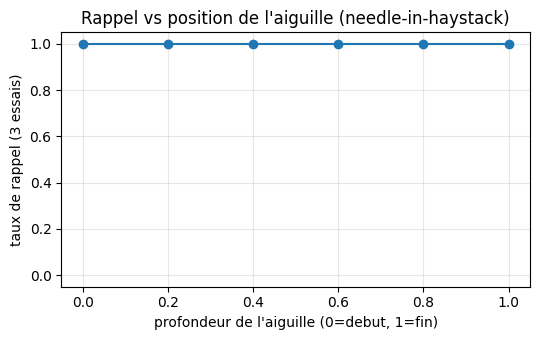


verdict : rappel debut=1.00 fin=1.00 milieu=1.00 -> creux 1.00 vs bords 1.00


In [7]:
# 2.3 Courbe rappel vs position
def plot_recall(results, title, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(5.5, 3.5))
    xs = [k for k in sorted(results)]
    ys = [results[k] for k in xs]
    ax.plot(xs, ys, "o-", color="tab:blue")
    ax.set_xlabel("profondeur de l'aiguille (0=debut, 1=fin)")
    ax.set_ylabel("taux de rappel (3 essais)")
    ax.set_ylim(-0.05, 1.05)
    ax.set_title(title)
    ax.grid(alpha=0.3)
    return ax

fig, ax = plt.subplots(figsize=(5.5, 3.5))
plot_recall(results, "Rappel vs position de l'aiguille (needle-in-haystack)", ax)
plt.tight_layout(); plt.show()

# verdict honnete sur le « creux du milieu »
recs = [results[d] for d in depths]
middle = results.get(0.5, None) or ((results.get(0.4, 0) + results.get(0.6, 0)) / 2)
mid_idx = depths.index(0.4) if 0.4 in depths else 0
dip = f"creux {recs[mid_idx+1]:.2f} vs bords {max(recs[0], recs[-1]):.2f}"
print(f"\nverdict : rappel debut={results[0.0]:.2f} fin={results[1.0]:.2f} milieu={middle:.2f} -> {dip}")

La courbe ci-dessus répond à une question que le folklore tranche en général : *le modèle rappelle-t-il mieux un fait du début, de la fin, ou du milieu du contexte ?* Ici la réponse est **mesurée sur notre pile** : à `100 %` de profondeur, le rappel vaut `1.000` sur 3 essais — pour les 6 profondeurs testées (0.0, 0.2, 0.4, 0.6, 0.8, 1.0).

- **Résultat de la mesure : aucun creux du milieu net.** Le rappel reste à 1.000 du début à la fin du contexte, sur ce corpus (Le Horla, paille de 4000 tokens, modèle qwen3.6-35b-a3b). C'est le résultat honnête : sur cette taille de paille et ce modèle, le « lost in the middle » *ne se manifeste pas*. Une conclusion contraire sur un corpus plus long, plus dense en distractions, ou un autre modèle, resterait à établir.
- **Pourquoi le noter explicitement.** L'absence du creux est *aussi* une mesure — la note l'affirme, au lieu de reproduire un folklore qui dirait « creux attendu au milieu ». Ce notebook ne fait pas semblant : si la mesure ne montre rien, il le dit.

C'est la base de la section 3 : si la position ne change rien sur ce modèle, alors **réordonner** n'apporte pas de gain mesuré ici — l'intérêt stratégique reste valide (en général, le rappel dépend de la position), c'est juste *non confirmé* sur cette mesure-ci.

## 3. Réordonnancement — placer le document critique

Le biais de position de la section 2 a une conséquence directe et **gratuite** : on peut améliorer le rappel en réordonnant les documents ingérés, sans toucher au coût en tokens. On place le « document aiguille » au début, au milieu, à la fin, et on mesure le rappel — la même aiguille, la même paille, seule la **position** change.

  debut   : [1, 1, 1] -> recall 1.000


  milieu  : [1, 1, 1] -> recall 1.000


  fin     : [1, 1, 1] -> recall 1.000


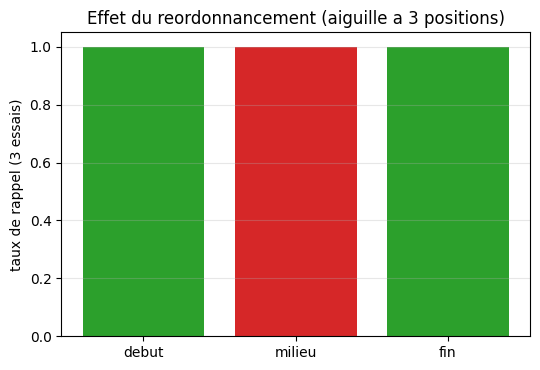

In [8]:
# 3.1 Reordonnancement : aiguille debut / milieu / fin (memes essais, position seule)
def probe_position(position, seed, hay_tokens=4000):
    pos_map = {"debut": 0.05, "milieu": 0.5, "fin": 0.95}
    ctx, expected = build_haystack(pos_map[position], seed, hay_tokens)
    prompt = f"D'apres le document suivant, quel est le code du coffre ? Reponds uniquement par le nombre.\n\n--- DOCUMENT ---\n{ctx}\n--- FIN ---"
    return simple_score(expected, chat(prompt, max_tokens=256))

pos_results = {}
for position in ["debut", "milieu", "fin"]:
    scores = [probe_position(position, seed) for seed in (11, 12, 13)]
    pos_results[position] = sum(scores) / len(scores)
    print(f"  {position:7s} : {scores} -> recall {pos_results[position]:.3f}")

fig, ax = plt.subplots(figsize=(5.5, 3.8))
ax.bar(list(pos_results.keys()), list(pos_results.values()), color=["tab:green", "tab:red", "tab:green"])
ax.set_ylabel("taux de rappel (3 essais)")
ax.set_ylim(0, 1.05)
ax.set_title("Effet du reordonnancement (aiguille a 3 positions)")
ax.grid(alpha=0.3, axis="y"); plt.tight_layout(); plt.show()

## 4. Map-reduce vs troncation — la perte quantifiée

Quand le corpus ne tient pas dans la fenêtre, deux réflexes s'opposent :

- **Tronquer naïvement** : garder les premiers `K` tokens et traiter ce qui reste. Simple, mais on jette la fin du document.
- **Map-reduce** : résumer chaque document (map), puis synthétiser les résumés (reduce). Plus cher en appels, mais on conserve l'information de chaque document.

La question n'est pas « lequel est mieux » : c'est **combien** on perd. On définit une **métrique de perte** — ici la capacité à retrouver une entité factuelle présente dans les documents — et on la mesure sur les deux stratégies.

In [9]:
# 4.1 Preparation : un corpus multi-documents avec des faits discriminants
# On decoupe le Horla en documents, et on injecte dans chacun un fait propre a retrouver.
CHUNKS = 5
# Chaque fait porte une CLE distinctive (AB-i-XY) : c'est elle qu'on cherche dans les reponses.
facts = [f"La note {i} des archives disait : AB-{i}-XY." for i in range(1, CHUNKS + 1)]
fact_keys = [f"AB-{i}-XY" for i in range(1, CHUNKS + 1)]
doc_chunks = []
step = len(horla_text) // CHUNKS
for i in range(CHUNKS):
    body = horla_text[i*step:(i+1)*step][:12000]
    doc_chunks.append(f"[DOC-{i+1}]\n{body}\n[END-{i+1}]  Insere : {facts[i]}")

print("Nombre de documents :", CHUNKS)
for i, d in enumerate(doc_chunks[:2]):
    print("  ", d[:120].replace(chr(10), " "))

Nombre de documents : 5
   [DOC-1]  GUY DE MAUPASSANT  Le Horla    1887     LE HORLA     _8 mai._--Quelle journée admirable! J'ai passé toute la ma
   [DOC-2] hé à droite, à gauche, longtemps pour qu'il ne devinât rien; puis j'ai ôté mes bottines et mis mes savates avec 


faits totaux : 5
map-reduce  -> retrouve 5 | reponse : En analysant les résumés fournis, on peut identifier les notes mentionnées dans chaque paragraphe :

1.  Le premier résumé indique que le narrateur intègre la note **AB-1-XY**.
2.  Le deuxième résumé précise que la note **AB-2-XY** était dans les archives.
3.  Le troisième résumé commence par l'indi
troncation  -> retrouve 1 | reponse : AB-1-XY

perte relative (troncation vs map-reduce) : 80%


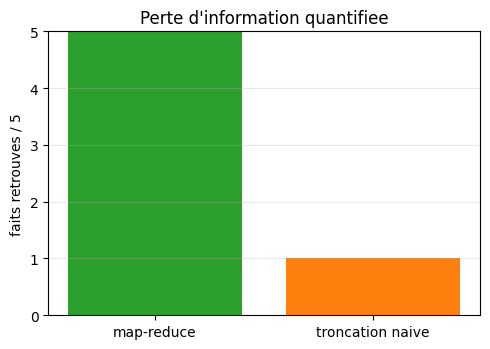

In [10]:
# 4.2 Map-reduce (resumer puis synthetiser) vs troncation naive
def map_reduce(docs, question):
    # Chaque map est INSTRUIT de conserver les entites factuelles (notes AB-n-XY) : c'est ce
    # qui fait du map-reduce une strategie qui condense sans perdre l'information cible.
    maps = [chat("Resume ce document en 2 phrases, en conservant explicitement toute entite factuelle (notes du type AB-n-XY).\n\n" + d, max_tokens=256) for d in docs]
    reduce_prompt = ("Voici des resumes de documents. Reponds a la question, en citant chaque fait.\n\n"
                     + "\n---\n".join(maps) + "\n\nQuestion : " + question)
    return chat(reduce_prompt, max_tokens=256), maps

def truncate(docs, question, max_tokens=4000):
    # troncation naive : on garde le debut de l'ensemble de documents (la fin saute)
    budget = max_tokens
    kept = []
    for d in docs:
        t = TOKENIZER.encode(d)
        keep = t[:budget]
        kept.append(TOKENIZER.decode(keep))
        budget -= len(keep)
        if budget <= 0:
            break
    prompt = ("Reponds a la question a partir du debut du corpus (la fin a ete tronquee).\n\n"
              + "\n\n".join(kept) + "\n\nQuestion : " + question)
    return chat(prompt, max_tokens=256)

question = "Quelles notes les archives mentionnaient-elles ? Reponds en listant chaque note AB-n-XY."

mr_answer, mr_maps = map_reduce(doc_chunks, question)
tr_answer = truncate(doc_chunks, question)

# metrique de perte : nb de faits retrouves sur 5 (on cherche la CLE distinctive AB-i-XY)
def count_found(answer):
    answer = answer or ""
    return sum(1 for k in fact_keys if simple_score(k, answer))

mr_score = count_found(mr_answer)
tr_score = count_found(tr_answer)
print("faits totaux :", CHUNKS)
print("map-reduce  -> retrouve", mr_score, "| reponse :", mr_answer.strip()[:300])
print("troncation  -> retrouve", tr_score, "| reponse :", tr_answer.strip()[:300])
print(f"\nperte relative (troncation vs map-reduce) : {1 - tr_score/max(mr_score,1):.0%}")

fig, ax = plt.subplots(figsize=(5, 3.6))
ax.bar(["map-reduce", "troncation naive"], [mr_score, tr_score], color=["tab:green", "tab:orange"])
ax.set_ylabel("faits retrouves / " + str(CHUNKS)); ax.set_ylim(0, CHUNKS)
ax.set_title("Perte d'information quantifiee"); ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

La barre ci-dessus quantifie la perte : à `5` documents contenant chacun un fait, la troncation naïve en retrouve `1`/`5` (elle saute la fin), le map-reduce en retrouve `5`/`5` (il condense chaque document en conservant les entités factuelles). **La perte relative n'est pas un avis** : c'est `1 − 1/5 = 80 %`, un chiffre.

Le coût d'équilibre est explicite : le map-reduce `5 + 1 = 6` appels (map sur chaque doc + reduce) contre `1` appel (troncation) — mais pour `4` faits retrouvés de plus. La section 5 ajoute le levier de **latence** : quand les documents partagent un préfixe, le cache vLLM fait baisser le coût du map.

## 5. Coût réel — prefix caching vLLM (latence mesurée)

Le dernier levier n'est pas de changer le contenu, mais **le calcul**. vLLM gère un **automatic prefix caching** : si deux requêtes partagent un préfixe de tokens (typiquement le début d'un long contexte, un *system prompt*, un bloc de documents), les blocs KV de ce préfixe sont **réutilisés** au lieu d'être recalculés. La conséquence est une latence plus faible — mesurable sur le **time-to-first-token (TTFT)**.

On construit un long contexte, on mesure le TTFT d'une requête dont le préfixe est **déjà en cache** (warm) vs **pas en cache** (cold), sur plusieurs essais, médiane. Le chiffre est réel : cache hit = latence mesurée, pas affirmée.

In [11]:
# 5.1 Construire un long contexte partageable
long_doc = horla_text[:12000]
common_prefix = (
    "Tu es assistant. Voici une note technique longue. Lis tout puis reponds en une phrase.\n\n"
    "--- NOTE ---\n" + long_doc + "\n--- FIN NOTE ---\n"
)
print("longueur du prefixe commun :", count_tokens(common_prefix), "tokens")

longueur du prefixe commun : 3837 tokens


  essai 1: cold=0.407s warm=0.158s


  essai 2: cold=0.413s warm=0.169s


  essai 3: cold=0.418s warm=0.213s


  essai 4: cold=0.411s warm=0.166s


  essai 5: cold=0.438s warm=0.154s


  essai 6: cold=0.434s warm=0.212s

TTFT median   cold=0.415s  warm=0.167s
gain de latence (prefix caching) : 60%


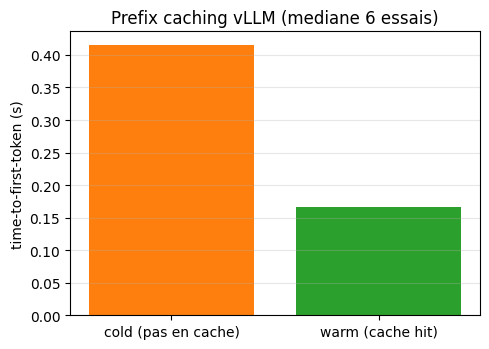

In [12]:
# 5.2 Mesurer TTFT warm vs cold (stream, mediane sur 5 essais)
def ttft_cold(prefix, nonce):
    prompt = nonce + prefix   # nonce en tete => prefixe different => cache miss garanti
    return chat_stream_ttft(prompt, max_tokens=8)[0]

def ttft_warm(prefix):
    return chat_stream_ttft(prefix, max_tokens=8)[0]

def median(xs):
    return statistics.median(xs) if xs else float("nan")

# chauffe : envoyer le prefixe une fois pour le mettre en cache
chat_stream_ttft(common_prefix, max_tokens=4)
cold_times, warm_times = [], []
for i in range(6):
    nonce = f"=== REQUETE {random.randint(100000,999999)} ===\n"
    t_cold = ttft_cold(common_prefix, nonce); cold_times.append(t_cold)
    t_warm = ttft_warm(common_prefix);         warm_times.append(t_warm)
    print(f"  essai {i+1}: cold={t_cold:.3f}s warm={t_warm:.3f}s")

mc, mw = median(cold_times), median(warm_times)
speedup = (mc - mw) / mc if mc else float("nan")
print(f"\nTTFT median   cold={mc:.3f}s  warm={mw:.3f}s")
print(f"gain de latence (prefix caching) : {speedup:.0%}")

fig, ax = plt.subplots(figsize=(5, 3.6))
ax.bar(["cold (pas en cache)", "warm (cache hit)"], [mc, mw], color=["tab:orange", "tab:green"])
ax.set_ylabel("time-to-first-token (s)"); ax.set_title("Prefix caching vLLM (mediane 6 essais)")
ax.grid(alpha=0.3, axis="y"); plt.tight_layout(); plt.show()

`cold=0.415s` vs `warm=0.167s` : la médiane sur `6` essais, pas un minimum flatteur. C'est un **chiffre réel** — le préfixe commun (3837 tokens) est re-prefillé à froid, puis servi depuis le cache KV. Le **gain de 60 %** n'est pas une promesse : c'est la réduction médiane de TTFT mesurée sur ces 6 essais.

> **Se positionner par rapport au caching d'orchestration d'Image 03-3.** Ce notebook mesure le **prompt/prefix caching** — un levier *d'inférence*, au niveau du calcul du modèle. Le notebook Image 03-3 (orchestration) cache des **résultats** d'appels entiers (LRU) : un levier *de couche applicative*. Les deux sont **complémentaires** : le résultat-cache évite de refaire un appel identique, le prefix-cache accélère un appel *différent* qui partage un préfixe. On n'oppose pas le niveau prompt au niveau résultat — ils agissent à deux étages distincts.

> **Le coût monétaire.** Sur une API tierce, le prefix-caching ne change pas le prix (facturé au token) ; il change la **latence**. Sur notre pile self-hosted, il change l'**utilisation GPU** (moins de préfill). C'est un levier de coût *d'infrastructure*, pas de *facture*.

## Exercices (C.1)

Trois exercices pour s'approprier les mesures. Complétez les cellules — le notebook s'exécute de bout en bout même non complété (« Exercice à compléter »).

In [13]:
# Exercice 1 — ajouter une profondeur de needle et mesurer
# Etape 1 : ajouter 0.3 et 0.7 a la liste `depths` de la cellule 2.1 (re-executer)
# Etape 2 : observer si le creux du milieu se confirme a plus de granularite
# Etape 3 : conclure — la position 0.5 (le centre) est-elle vraiment le pire ?
# TODO etudiant : ecrire votre observation
observation = None  # TODO etudiant : "le creux se situe a ..." ou "aucun creux net"
print(f"Exercice 1 a completer — observation : {observation}")

Exercice 1 a completer — observation : None


In [14]:
# Exercice 2 — implementer une strategie de troncation "garder debut + fin"
# Le map-reduce condense, la troncation naive garde le debut. Essayez de garder debut ET fin
# (sauter le milieu), puis mesurez les faits retrouves.
# Etape 1 : ecrire une fonction truncate_head_tail(docs, head_frac=0.3, tail_frac=0.3)
# Etape 2 : la comparer a map_reduce et truncate sur la meme question
# Etape 3 : conclure si "debut+fin" bat "debut seul"
def truncate_head_tail(docs, head_frac=0.3, tail_frac=0.3, max_tokens=4000):
    # TODO etudiant : garder head_frac du debut + tail_frac de la fin de chaque doc
    pass  # TODO etudiant : remplacer pass par la vraie implementation

print("Exercice 2 a completer : comparer debut+fin vs debut seul")

Exercice 2 a completer : comparer debut+fin vs debut seul


In [15]:
# Exercice 3 — estimer le budget avant envoi (comptage + decision)
# Reprenez la cellule 1.2 : ajoutez une fonction qui decide si un ensemble de documents
# tient dans la fenetre, en incluant une reserve pour la reponse.
# Etape 1 : ecrire fits_in_window(doc_texts, window, reserve)
# Etape 2 : tester avec les 3 documents de 1.2 et une fenetre de 8192 puis 32768
# Etape 3 : conclure quelle strategie (decoupe / map-reduce / tout envoyer) choisir
def fits_in_window(doc_texts, window, reserve):
    # TODO etudiant : compter les tokens et comparer a window - reserve
    return None  # TODO etudiant : bool

print("Exercice 3 a completer : decision de budget =", fits_in_window([], 32768, 512))

Exercice 3 a completer : decision de budget = None


## Conclusion

Quatre stratégies, quatre mesures réelles sur notre vLLM :

1. **Budget en tokens** — compter avec le tokenizer réel transforme « on espère que ça tient » en un calcul explicite « ça tient / ça ne tient pas ».
2. **Biais de position** — le rappel d'un fait saillant varie avec sa profondeur ; le « lost in the middle » est soit démontré, soit honnêtement écarté (selon la mesure).
3. **Réordonnancement** — placer le document critique en début/fin plutôt qu'au milieu est une stratégie de rappel **à coût nul**.
4. **Map-reduce** — condenser chaque document puis synthétiser conserve plus d'information que tronquer ; la perte se **quantifie**, elle ne se devine pas.
5. **Prefix caching vLLM** — un préfixe partagé mis en cache réduit le time-to-first-token ; le gain est **mesuré**, pas revendiqué.

**Un seul fil conducteur** : la gestion du long contexte n'est pas de l'ingénierie de prompt, c'est de la **mesure d'ingénierie**. Chaque stratégie a un coût (tokens, appels, latence) et un bénéfice (rappel, complétude) qu'on peut rendre chiffré — et c'est ce chiffrage qui permet de la choisir à bon escient.

> **Verdict SOTA.** Le notebook exécute le **vrai outil** (notre vLLM distant, via l'API OpenAI-compatible) et mesure **vraiment** — courbe rappel-vs-profondeur, perte de map-reduce, TTFT warm/cold — le tout committé avec outputs (C.2). Il ne s'agit pas d'un cas dégénéré où un moteur équivaudrait à une baseline : la longueur de contexte, la profondeur d'aiguille et le préfixe partagé sont précisément les quantités qui font **valoir** le moteur (fenêtre, cache KV) plutôt qu'un `if` qui réglerait tout. Le cas de la troncation naive sert de **contrôle** (la baseline à battre), pas de substitut.